In [21]:
import sys
sys.path.append("../src/python")  # must come before utils imports

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import h5py
import re
from scipy import signal
from scipy.signal import butter, filtfilt
from scipy.signal import welch
from pathlib import Path
import logging
import importlib
from gwpy.timeseries import TimeSeries
import utils.data_loader
importlib.reload(utils.data_loader)
from utils.data_loader import load_hdf5_strain, get_strain_data_from_gwpy
from utils.preprocessing import *
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s",
    stream=sys.stdout,
    force=True
)
DATA_DIR = Path("../data/raw")

files = list(DATA_DIR.glob("*.hdf5"))
#print(files[0])
#print(files[1])

# Get URLs for GPS time 1264316101, 32-second segment
#you can try for : L-L1_GWOSC_4KHZ_R1-1264316101-32.hdf5
#get_strain_data_from_gwpy('H-H1_GWOSC_4KHZ_R1-1264316101-32', 'H1', 1264316101, 32, 4096)

In [2]:
strain_h = load_hdf5_strain(files[0])
strain_l = load_hdf5_strain(files[1])

2026-05-08 23:51:42,655 - INFO - Loaded HDF5 strain:
┌───────────────────────────────────────────────────────────────┐
│                      HDF5 Strain Dataset                      │
├───────────┬───────────────────────────────────────────────────┤
│ File      │ ../data/raw/H-H1_GWOSC_4KHZ_R1-1264316101-32.hdf5 │
│ Shape     │ (131072,)                                         │
│ dtype     │ float64                                           │
│ Size      │ 1.00 MB                                           │
├───────────┼───────────────────────────────────────────────────┤
│ Min       │ -1.729121e-19                                     │
│ Max       │ 1.706626e-19                                      │
│ Std       │ 4.661097e-20                                      │
├───────────┼───────────────────────────────────────────────────┤
│ NaN count │ 0                                                 │
│ Inf count │ 0                                                 │
└───────────┴──────────

In [3]:
sample_rate = 4096
# Time
time = np.arange(len(strain_h)) / sample_rate
print(time)
print(len(time))

[0.00000000e+00 2.44140625e-04 4.88281250e-04 ... 3.19992676e+01
 3.19995117e+01 3.19997559e+01]
131072


In [4]:
# Big z-scores = unusual → possible signal/event
#strain_h_norm = normalize_strain(strain_h)
#strain_l_norm = normalize_strain(strain_l)

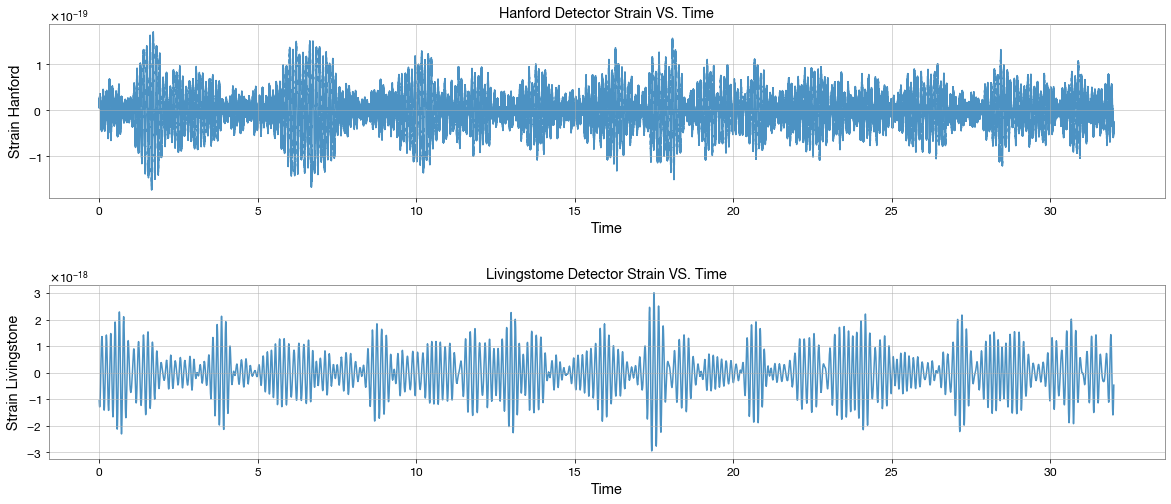

In [5]:
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(20, 8))

# Hanford Strain VS Time
axes[0].plot(time, strain_h, label="H1", alpha=0.8)
axes[0].set_title("Hanford Detector Strain VS. Time")
axes[0].set_xlabel("Time")
axes[0].set_ylabel("Strain Hanford")

# Livingstone Strain VS Time
axes[1].plot(time, strain_l, label="L1", alpha=0.8)
axes[1].set_title("Livingstome Detector Strain VS. Time")
axes[1].set_xlabel("Time")
axes[1].set_ylabel("Strain Livingstone")

fig.subplots_adjust(left=None,
    bottom=None,
    right=None,
    top=None,
    wspace=0.1,
    hspace=0.5,)


In [12]:
window_size = 4  # seconds
sample_rate = 4096

h1_segments = segment_signal(strain_h, window_size, sample_rate)
l1_segments = segment_signal(strain_l, window_size, sample_rate)

print("H1 segments shape:", h1_segments.shape)
print("L1 segments shape:", l1_segments.shape)

H1 segments shape: (8, 16384)
L1 segments shape: (8, 16384)


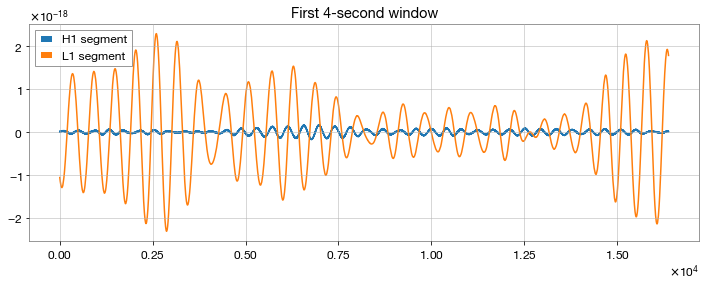

In [13]:
plt.figure(figsize=(12, 4))
plt.plot(h1_segments[0], label="H1 segment")
plt.plot(l1_segments[0], label="L1 segment")
plt.legend()
plt.title(f"First {window_size}-second window")
plt.show()

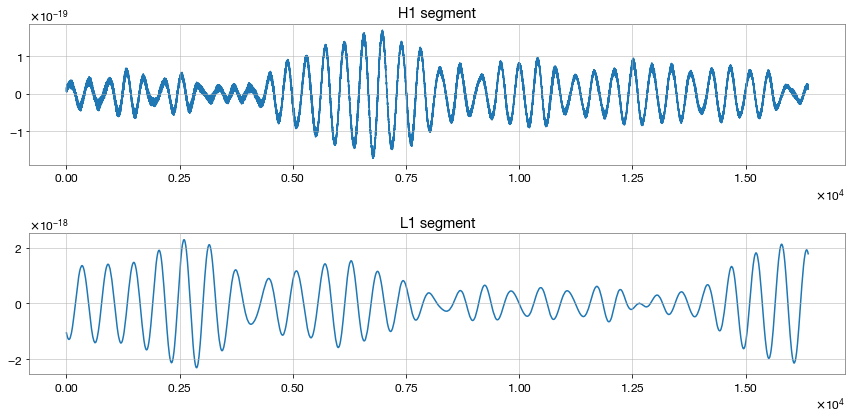

In [14]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6))

axes[0].plot(h1_segments[0])
axes[0].set_title("H1 segment")

axes[1].plot(l1_segments[0])
axes[1].set_title("L1 segment")

plt.tight_layout()
plt.show()

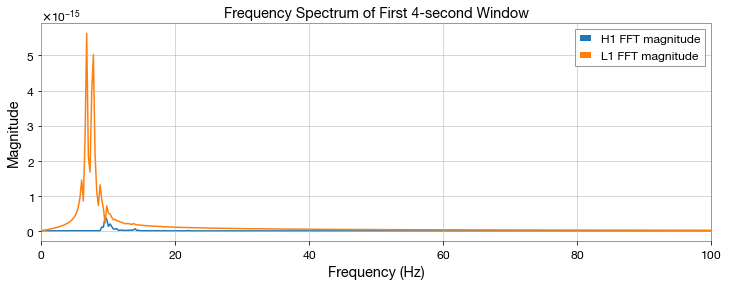

In [15]:
# Pick first 4-second window
h1_window = h1_segments[0]
l1_window = l1_segments[0]

sample_rate = 4096  # Hz

# FFT
h1_fft = np.fft.rfft(h1_window)
l1_fft = np.fft.rfft(l1_window)

# Frequency axis
freqs = np.fft.rfftfreq(len(h1_window), d=1/sample_rate)

# Magnitude
h1_mag = np.abs(h1_fft)
l1_mag = np.abs(l1_fft)

# Plot frequency spectrum
plt.figure(figsize=(12, 4))
plt.plot(freqs, h1_mag, label="H1 FFT magnitude")
plt.plot(freqs, l1_mag, label="L1 FFT magnitude")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.title("Frequency Spectrum of First 4-second Window")
plt.xlim(0, 100)  # focus on low frequencies first
plt.legend()
plt.grid(True)
plt.show()

In [18]:
3 + 2j

(3+2j)

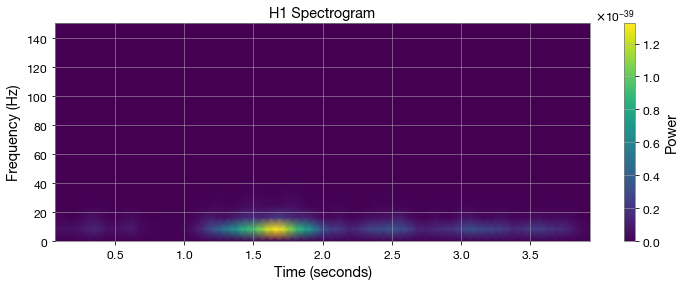

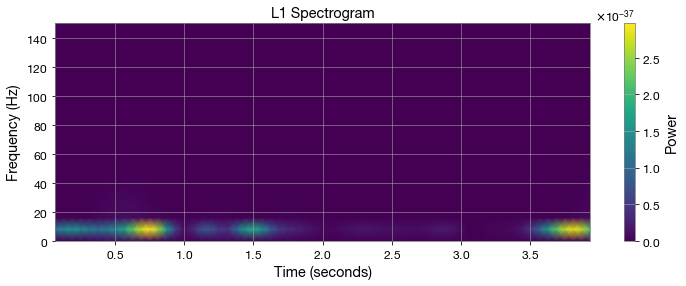

In [20]:
from scipy.signal import spectrogram

sample_rate = 4096

h1_window = h1_segments[0]
l1_window = l1_segments[0]

# Spectrogram
f_h1, t_h1, Sxx_h1 = spectrogram(
    h1_window,
    fs=sample_rate,
    nperseg=512,
    noverlap=256,
    scaling="density"
)

f_l1, t_l1, Sxx_l1 = spectrogram(
    l1_window,
    fs=sample_rate,
    nperseg=512,
    noverlap=256,
    scaling="density"
)

# Plot H1
plt.figure(figsize=(12, 4))
plt.pcolormesh(t_h1, f_h1, Sxx_h1, shading="gouraud")
plt.ylim(0, 150)
plt.xlabel("Time (seconds)")
plt.ylabel("Frequency (Hz)")
plt.title("H1 Spectrogram")
plt.colorbar(label="Power")
plt.show()

# Plot L1
plt.figure(figsize=(12, 4))
plt.pcolormesh(t_l1, f_l1, Sxx_l1, shading="gouraud")
plt.ylim(0, 150)
plt.xlabel("Time (seconds)")
plt.ylabel("Frequency (Hz)")
plt.title("L1 Spectrogram")
plt.colorbar(label="Power")
plt.show()

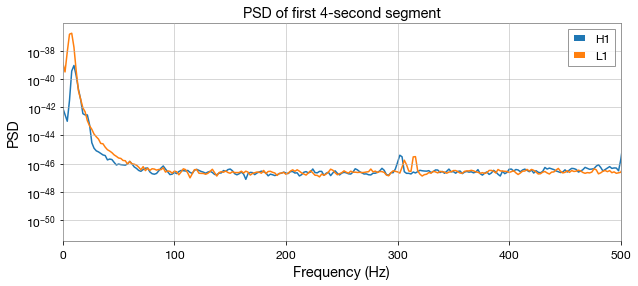

In [9]:
# Low frequency (20HZ) the frequency is low and amplitude/strength is high
# Low frequency + high amplitude in LIGO → usually noise (because of environment)
#Frequency → speed
#Amplitude → strength
#Noise vs signal → depends on context
freq_h, psd_h = welch(h1_segments[0], fs=sample_rate, nperseg=2048)
freq_l, psd_l = welch(l1_segments[0], fs=sample_rate, nperseg=2048) 

plt.figure(figsize=(10, 4))
plt.semilogy(freq_h, psd_h, label="H1")
plt.semilogy(freq_l, psd_l, label="L1")
plt.xlim(0, 500)
plt.xlabel("Frequency (Hz)")
plt.ylabel("PSD")
plt.title("PSD of first 4-second segment")
plt.legend()
plt.show()

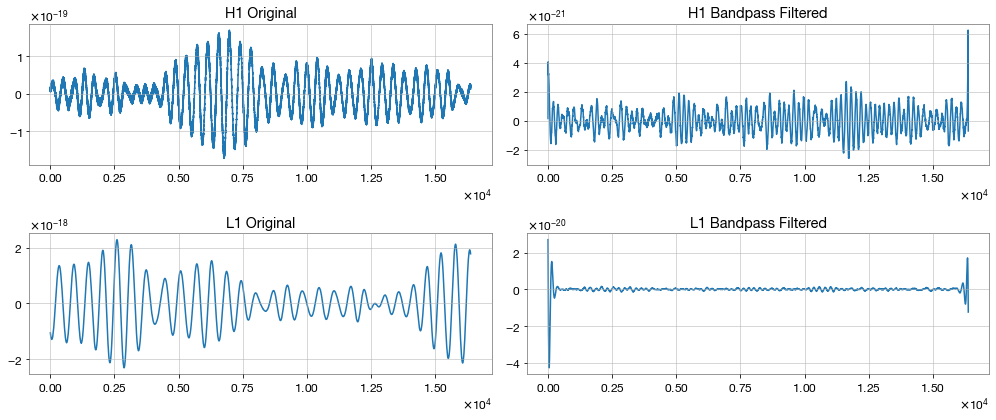

In [22]:
# -----------------------------
# Bandpass filter function
# -----------------------------
def bandpass_filter(signal, lowcut, highcut, fs, order=4):

    nyquist = 0.5 * fs

    low = lowcut / nyquist
    high = highcut / nyquist

    b, a = butter(order, [low, high], btype='band')

    filtered_signal = filtfilt(b, a, signal)

    return filtered_signal


# ---------------------------------
# Apply filter
# ---------------------------------
lowcut = 20
highcut = 300

h1_filtered = bandpass_filter(
    h1_segments[0],
    lowcut,
    highcut,
    sample_rate
)

l1_filtered = bandpass_filter(
    l1_segments[0],
    lowcut,
    highcut,
    sample_rate
)

# ---------------------------------
# Plot original vs filtered
# ---------------------------------
fig, axes = plt.subplots(2, 2, figsize=(14, 6))

# H1 original
axes[0,0].plot(h1_segments[0])
axes[0,0].set_title("H1 Original")

# H1 filtered
axes[0,1].plot(h1_filtered)
axes[0,1].set_title("H1 Bandpass Filtered")

# L1 original
axes[1,0].plot(l1_segments[0])
axes[1,0].set_title("L1 Original")

# L1 filtered
axes[1,1].plot(l1_filtered)
axes[1,1].set_title("L1 Bandpass Filtered")

plt.tight_layout()
plt.show()

In [10]:
#h1_bp = bandpass_filter(h1_segments[0], 20, 500, sample_rate)
#l1_bp = bandpass_filter(l1_segments[0], 20, 500, sample_rate)

h1_full_bp = bandpass_gwpy(strain_h, sample_rate)
l1_full_bp = bandpass_gwpy(strain_l, sample_rate)

In [11]:
h1_segments_bp = segment_signal(h1_full_bp, 4, sample_rate)
l1_segments_bp = segment_signal(l1_full_bp, 4, sample_rate)

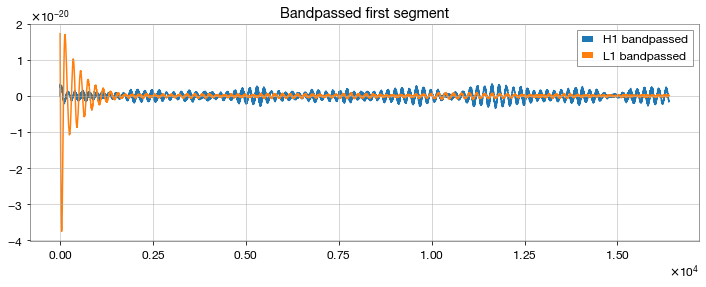

In [12]:
plt.figure(figsize=(12, 4))
plt.plot(h1_segments_bp[0], label="H1 bandpassed")
plt.plot(l1_segments_bp[0], label="L1 bandpassed")
plt.legend()
plt.title("Bandpassed first segment")
plt.show()

In [13]:
h1_full_white = whiten_gwpy(h1_full_bp, sample_rate)
l1_full_white = whiten_gwpy(l1_full_bp, sample_rate)

In [14]:
h1_segments_white = segment_signal(h1_full_white, 4, sample_rate)
l1_segments_white = segment_signal(l1_full_white, 4, sample_rate)

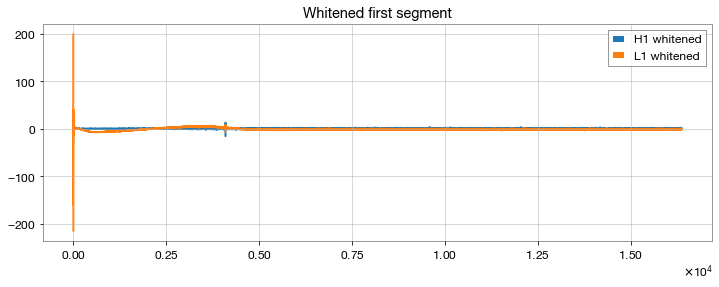

In [15]:
plt.figure(figsize=(12, 4))
plt.plot(h1_segments_white[0], label="H1 whitened")
plt.plot(l1_segments_white[0], label="L1 whitened")
plt.legend()
plt.title("Whitened first segment")
plt.show()